In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 统一颜色
# =========================
axis_colors = {
    'x': 'blue',
    'y': 'green',
    'z': 'red'
}

# =========================
# 读取原始CSV
# =========================
file_path = "BAT_Heat_Log_Data_2026_05_21_16_59_17.csv"

df = pd.read_csv(file_path)

# 清理列名
df.columns = df.columns.str.strip()

# 空白转 NaN
df = df.replace(r'^\s*$', np.nan, regex=True)

# =========================
# 只保留图一需要的加速度滤波后数据
# =========================
needed_cols = [
    'UTC_Time',
    'Accel_x_h',
    'Accel_y_h',
    'Accel_z_h'
]

df_plot1 = df[needed_cols].copy()

# 时间解析，仅作参考
df_plot1['UTC_Time'] = pd.to_datetime(
    df_plot1['UTC_Time'],
    format='%Y_%m_%d_%H_%M_%S.%f',
    errors='coerce'
)

# 转数值
for col in ['Accel_x_h', 'Accel_y_h', 'Accel_z_h']:
    df_plot1[col] = pd.to_numeric(df_plot1[col], errors='coerce')

# 删除无效行
df_plot1 = df_plot1.dropna(subset=['Accel_x_h', 'Accel_y_h', 'Accel_z_h']).reset_index(drop=True)

# =========================
# 构造 Qt 程序一致的横坐标
# Qt里 LOG_Time = sample_index / 50
# =========================
fs = 50
dt = 1 / fs

df_plot1['time_sec'] = np.arange(len(df_plot1)) * dt

print("数据长度:", len(df_plot1))
print("时间长度约:", df_plot1['time_sec'].iloc[-1], "s")


数据长度: 12500
时间长度约: 249.98000000000002 s


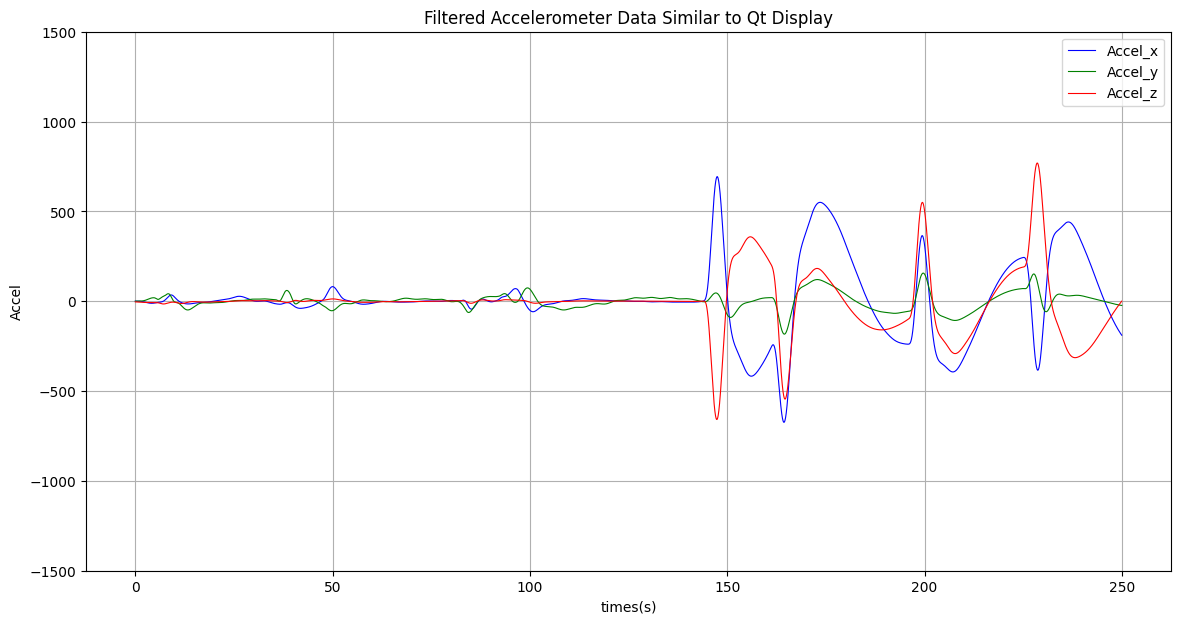

In [3]:
plt.figure(figsize=(14, 7))

plt.plot(
    df_plot1['time_sec'],
    df_plot1['Accel_x_h'],
    label='Accel_x',
    color=axis_colors['x'],
    linewidth=0.8
)

plt.plot(
    df_plot1['time_sec'],
    df_plot1['Accel_y_h'],
    label='Accel_y',
    color=axis_colors['y'],
    linewidth=0.8
)

plt.plot(
    df_plot1['time_sec'],
    df_plot1['Accel_z_h'],
    label='Accel_z',
    color=axis_colors['z'],
    linewidth=0.8
)

plt.xlabel("times(s)")
plt.ylabel("Accel")
plt.title("Filtered Accelerometer Data Similar to Qt Display")

# 和Qt程序一致
plt.ylim(-1500, 1500)

plt.legend()
plt.grid(True)
plt.show()

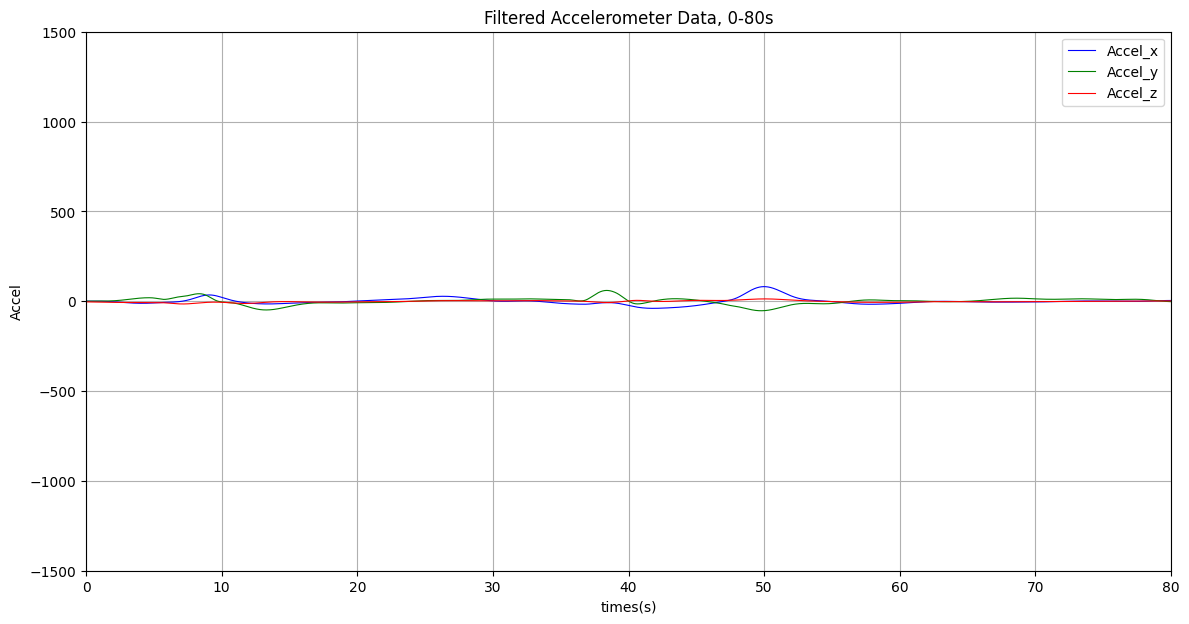

In [ ]:
# =========================
# 截取前x秒
# =========================
df_plot1_80s = df_plot1[df_plot1['time_sec'] <= 80].copy()

plt.figure(figsize=(14, 7))

plt.plot(
    df_plot1_80s['time_sec'],
    df_plot1_80s['Accel_x_h'],
    label='Accel_x',
    color=axis_colors['x'],
    linewidth=0.8
)

plt.plot(
    df_plot1_80s['time_sec'],
    df_plot1_80s['Accel_y_h'],
    label='Accel_y',
    color=axis_colors['y'],
    linewidth=0.8
)

plt.plot(
    df_plot1_80s['time_sec'],
    df_plot1_80s['Accel_z_h'],
    label='Accel_z',
    color=axis_colors['z'],
    linewidth=0.8
)

plt.xlabel("times(s)")
plt.ylabel("Accel")
plt.title("Filtered Accelerometer Data, 0-80s")

plt.xlim(0, 80)
plt.ylim(-1500, 1500)

plt.legend()
plt.grid(True)
plt.show()